# Praktikum Pemrograman - Minggu 7 (UTS)

---
## 07A. Total Belanja
### Description
Sebuah toko menjual satu jenis barang dengan harga tertentu, misalkan $p$ rupiah. Pembeli dapat membeli barang tersebut. Setiap pembelian dikenakan pajak 10% dari total nilainya. Buat program C untuk menghitung dan menampilkan total harga yang harus dibayar jika dilakukan pembelian sebanyak $n$ buah.

### Input Format
Input data diberikan dengan format: `p n` ($1000 \le p \le 2000000$ dan $1 \le n \le 1000$)

### Output Format
Total harga yang harus dibayar setelah dikenakan pajak 10%. Nilai output ditampilkan dengan 2 digit di belakang tanda desimal.

### Sample Input
```
5000 10
```
### Sample Output
```
55000.00
```

### Thought Process
Soal ini menguji pemahaman operasi aritmatika dasar dan tipe data *floating point* (`double`). 
1. Hitung harga awal: $HargaAwal = p \times n$.
2. Hitung pajak: $Pajak = 10\% \times HargaAwal$ (bisa ditulis `0.1 * HargaAwal`).
3. Hitung harga akhir: $HargaAkhir = HargaAwal + Pajak$.
4. Cetak menggunakan `%.2lf` untuk membatasi 2 digit desimal.

In [1]:
%%writefile practicumWeek7a.c
#include <stdio.h>

int main() {
  double hargaBarang = 0;
  double hargaAwal = 0;
  double jumlahBarang = 0;
  double pajak = 0;
  double hargaAkhir = 0;
  
  scanf("%lf %lf", &hargaBarang, &jumlahBarang);
  
  hargaAwal = (hargaBarang*1.0) * jumlahBarang;
  pajak = (10.00/100) * hargaAwal;
  hargaAkhir = hargaAwal + pajak;
  
  printf("%.2lf\n", hargaAkhir);
  
  return 0;
}

Overwriting practicumWeek7a.c


In [2]:
!gcc practicumWeek7a.c -o practicumWeek7a && echo 5000 10 | practicumWeek7a.exe

55000.00


---
## 07B. Analisis Penjualan
### Description
Toko elektronik "Stroberi Tech" selalu melakukan analisis penjualan selama seminggu. Analisis dilakukan dengan mencatat nilai total penjualan per hari selama seminggu, mulai dari Minggu, Senin, sampai dengan Sabtu ($A_1, A_2, A_3, A_4, A_5, A_6, A_7$). Dari data ini, pemilik toko menghitung dan menampilkan rata-rata nilai per hari, nilai penjualan tertinggi, dan hari paling awal dalam seminggu dimana terjadi nilai penjualan tertinggi.

### Input Format
Input data berupa 7 nilai bilangan bulat.

### Output Format
Tiga nilai dalam 3 baris:
1. Rata-rata nilai per hari (2 digit desimal).
2. Nilai penjualan tertinggi.
3. Hari paling awal dalam seminggu dimana terjadi nilai penjualan tertinggi (Minggu, Senin, ...).

### Sample Input
```
5000000 450000 125000 5000 5000000 1255000 4000
```
### Sample Output
```
1691285.71
5000000
Minggu
```

### Thought Process
Karena kita perlu mengetahui hari spesifik tempat *maximum* itu terjadi, menggunakan *Array* sangat dianjurkan.
1. Baca 7 data dan masukkan ke dalam array `daftarPenjualan[7]`. Sambil membaca, akumulasikan ke variabel `total` untuk menghitung rata-rata nantinya.
2. Lakukan iterasi untuk mencari nilai terbesar (`maximum`).
3. Lakukan iterasi lagi untuk mencari indeks hari pertama yang nilainya sama dengan `maximum`. Simpan indeksnya di variabel `hari`, lalu gunakan `break` agar pencarian langsung berhenti di hari paling awal.
4. Cetak rata-rata, maximum, dan gunakan `if-else` untuk memetakan indeks (0-6) ke nama hari.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penjualan(data):
    hari = ['Minggu', 'Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu']
    
    plt.figure(figsize=(8, 4))
    bars = plt.bar(hari, data, color='skyblue', edgecolor='black')
    
    # Menyoroti nilai maksimum paling awal
    max_val = max(data)
    max_idx = data.index(max_val)
    bars[max_idx].set_color('orange')
    bars[max_idx].set_edgecolor('black')
    
    plt.axhline(np.mean(data), color='red', linestyle='--', label=f'Rata-rata: {np.mean(data):.2f}')
    plt.title("Analisis Penjualan Mingguan")
    plt.ylabel("Pendapatan (Rp)")
    plt.legend()
    plt.show()

plot_penjualan([5000000, 450000, 125000, 5000, 5000000, 1255000, 4000])

In [ ]:
%%writefile practicumWeek7b.c
#include <stdio.h>

int main() {
  int daftarPenjualan[7] = {0};
  int total = 0;
  double rataRata = 0;
  int maximum = 0;
  int hari = 0;
  // 0 = minggu, 1 = senin, 2 = selasa, ...
  
  for (int i = 0; i < 7; i++) {
    scanf("%d", &daftarPenjualan[i]);
    total += daftarPenjualan[i];
  }
  
  rataRata = (total*1.0)/7.0;
  
  for (int i = 0; i < 7; i++) {
    if (daftarPenjualan[i] > maximum) {
      maximum = daftarPenjualan[i];
    }
  }
  
  for (int i = 0; i < 7; i++) {
    if (daftarPenjualan[i] == maximum) {
      hari = i;
      break;
    }
  }
  
  printf("%.2lf\n%d\n", rataRata, maximum);
  
  if (hari == 0) {
    printf("Minggu\n");
  } else if (hari == 1) {
    printf("Senin\n");
  } else if (hari == 2) {
    printf("Selasa\n");
  } else if (hari == 3) {
    printf("Rabu\n");
  } else if (hari == 4) {
    printf("Kamis\n");
  } else if (hari == 5) {
    printf("Jumat\n");
  } else if (hari == 6) {
    printf("Sabtu\n");
  }
  
  return 0;
}

Overwriting practicumWeek7b.c


In [ ]:
!gcc practicumWeek7b.c -o practicumWeek7b && echo 5000000 450000 125000 5000 5000000 1255000 4000 | practicumWeek7b.exe

1691285.71
5000000
Minggu


---
## 07C. Analisis Curah Hujan BMKG
### Description
Menghitung rata-rata curah hujan harian pada selang hari tertentu (hari ke-$a$ sampai dengan hari ke-$b$). Hal ini dilakukan beberapa kali (sebanyak $q$ kali query).

### Input Format
Baris 1: bilangan $n$ dan $q$ ($1 \le n \le 50000$, $1 \le q \le 20000$)
Baris 2: $n$ bilangan bulat curah hujan harian.
Baris 3 dan seterusnya: pasangan rentang $a$ dan $b$.

### Output Format
Program menampilkan rata-rata per query dengan format `Hari ke a-b: <rata-rata>`.

### Sample Input
```
10 4
10 20 30 40 50 0 0 0 0 0 
1 1
1 5
2 4
1 10
```
### Sample Output
```
Hari ke 1-1: 10.00
Hari ke 1-5: 30.00
Hari ke 2-4: 30.00
Hari ke 1-10: 15.00
```

### Thought Process
Ini adalah problem *Range Query*. Logika yang kamu tuliskan adalah pendekatan langsung (*Brute Force*):
1. Simpan semua data hujan di array.
2. Saat mendapatkan batas `a` dan `b`, lakukan perulangan `for` dari `a-1` hingga `b-1`.
3. Jumlahkan elemennya, bagikan dengan $(b - a) + 1$, lalu cetak.

*Catatan Efisiensi (Penting untuk Pengetahuan):*
Kode di bawah bisa lulus jika tes kasus Judgels tidak terlalu ketat, tetapi jika $n = 50.000$ dan $q = 20.000$, *loop* di dalam *loop* bisa melakukan hingga 1 Milyar operasi dan mungkin kena *Time Limit Exceeded* (TLE) karena batas waktunya sangat sempit (100 ms). Jika hal itu terjadi, kamu perlu menggunakan metode **Prefix Sum** (menyimpan total kumulatif hujan sejak hari pertama di sebuah array, sehingga perhitungan range $A$ ke $B$ cukup dikurangi: `Total = Prefix[b] - Prefix[a-1]`), yang mengubah perhitungan menjadi kilat tanpa perlu *looping* ulang di setiap query.

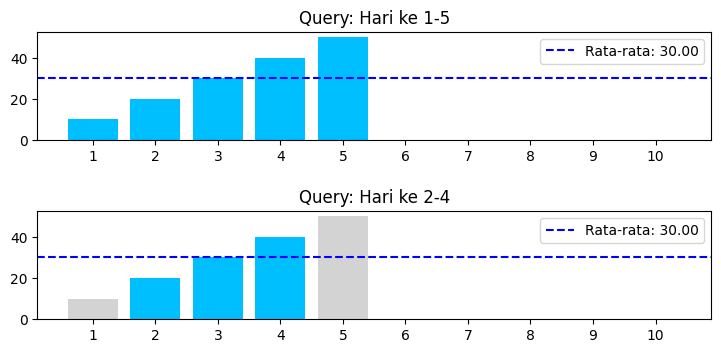

In [ ]:
import matplotlib.pyplot as plt

def plot_hujan(data, queries):
    hari = list(range(1, len(data) + 1))
    
    fig, axs = plt.subplots(len(queries), 1, figsize=(8, 2 * len(queries)))
    fig.tight_layout(pad=3.0)
    
    for idx, (a, b) in enumerate(queries):
        ax = axs[idx] if len(queries) > 1 else axs
        ax.bar(hari, data, color='lightgray')
        
        # Highlight rentang query
        rentang = list(range(a, b + 1))
        nilai_rentang = data[a-1:b]
        rata = sum(nilai_rentang) / len(nilai_rentang)
        
        ax.bar(rentang, nilai_rentang, color='deepskyblue')
        ax.axhline(rata, color='blue', linestyle='--', label=f'Rata-rata: {rata:.2f}')
        
        ax.set_title(f"Query: Hari ke {a}-{b}")
        ax.set_xticks(hari)
        ax.legend()
        
    plt.show()

plot_hujan([10, 20, 30, 40, 50, 0, 0, 0, 0, 0], [(1, 5), (2, 4)])

In [ ]:
%%writefile practicumWeek7c.c
#include <stdio.h>

int main() {
  int jumlahHari = 0;
  int jumlahPengulangan = 0;
  int daftarHujan[50000] = {0};
  int a, b; // selang
  int total = 0;
  double rataRata = 0;
  
  scanf("%d %d", &jumlahHari, &jumlahPengulangan);
  
  for (int i = 0; i < jumlahHari; i++) {
    scanf("%d", &daftarHujan[i]);
  }
  
  for (int i = 0; i < jumlahPengulangan; i++) {
    scanf("%d %d", &a, &b);
    
    for (int j = a-1; j < b; j++) {
      total += daftarHujan[j];
    }
    
    rataRata = (total*1.0)/((b-a)+1);
    
    printf("Hari ke %d-%d: %.2lf\n", a, b, rataRata);
    
    total = 0;
  }
  
  return 0;
}

Overwriting practicumWeek7c.c


In [ ]:
!gcc practicumWeek7c.c -o practicumWeek7c && echo 10 4 10 20 30 40 50 0 0 0 0 0 1 1 1 5 2 4 1 10 | practicumWeek7c.exe

Hari ke 1-1: 10.00
Hari ke 1-5: 30.00
Hari ke 2-4: 30.00
Hari ke 1-10: 15.00


### Alternative solution
The above solution utilizes regular array indexing to find the average within a certain range. But the issue is that the complexity is $O(n^2)$. To make it into linear $O(n)$, we could use `prefix-sum`.

In [ ]:
%%writefile practicumWeek7cPrefixSum.c
#include <stdio.h>

int main() {
  int jumlahHari = 0;
  int jumlahPengulangan = 0;
  int daftarHujan[50000] = {0};
  
  long long PS[50000] = {0};
  int a, b, indexA, indexB; // selang
  long long total = 0;
  double rataRata = 0;
  
  scanf("%d %d", &jumlahHari, &jumlahPengulangan);
  
  for (int i = 0; i < jumlahHari; i++) {
    scanf("%d", &daftarHujan[i]);
  }
  
  PS[0] = daftarHujan[0];

  for (int i = 1; i < jumlahHari; i++) {
    PS[i] = daftarHujan[i] + PS[i-1];
  }

  for (int i = 0; i < jumlahPengulangan; i++) {
    // hari ke 1-3 artinya total dari index 0-2
    scanf("%d %d", &a, &b);

    indexA = a - 1;
    indexB = b - 1;

    if ((indexA) == 0) {
      total = PS[indexB];
    } else if (a > 0) {
      total = PS[indexB] - PS[indexA-1];
    } else {
      total = 0;
    }

    rataRata = (total*1.0)/((b-a)+1);

    printf("Hari ke %d-%d: %.2lf\n", a, b, rataRata);
  }
  
  return 0;
}

Overwriting practicumWeek7cPrefixSum.c


In [ ]:
!gcc practicumWeek7cPrefixSum.c -o practicumWeek7cPrefixSum && echo 10 4 10 20 30 40 50 0 0 0 0 0 1 1 1 5 2 4 1 10 | practicumWeek7cPrefixSum.exe

Hari ke 1-1: 10.00
Hari ke 1-5: 30.00
Hari ke 2-4: 30.00
Hari ke 1-10: 15.00


The above solution works well as it follows the formula of prefix-sum which is:
- If $a = 0$ then total from a to b = $PS[b]$.
- If $a > 0$ then total from a to b = $PS[b] - PS[a-1]$.

Since we saved day 1 as `daftarHujan[0]`, when the user asks for average of day 2 to 4 we'll be needing the total from index `a = 1` to `b = 3` instead. This method is called `0-based indexing`. Because of this, we'll need to apply the specific condition where `a = 0` for when the user asks the total from day 1.

But, there's a more effective solution for problems where it uses 1 as the starting index known as `1-based indexing`. The approach is to store day 1 at index 1 so that when the user asks for day 1, we'll take from `a = 1` directly which means `a > 0` is always true.

In [ ]:
%%writefile practicumWeek7cPrefixSum2.c
#include <stdio.h>

int main() {
  int jumlahHari = 0;
  int jumlahPengulangan = 0;
  
  long long PS[50005] = {0}; 
  int a, b; // selang
  long long total = 0;
  double rataRata = 0;
  
  scanf("%d %d", &jumlahHari, &jumlahPengulangan);
  
  // Hari ke-1 = index 1
  for (int i = 1; i <= jumlahHari; i++) {
    long long hujan;
    scanf("%lld", &hujan);
    PS[i] = PS[i-1] + hujan; 
  }

  for (int i = 0; i < jumlahPengulangan; i++) {
    scanf("%d %d", &a, &b);

    total = PS[b] - PS[a-1];
    rataRata = (total * 1.0) / ((b - a) + 1);

    printf("Hari ke %d-%d: %.2lf\n", a, b, rataRata);
  }
  
  return 0;
}

Overwriting practicumWeek7cPrefixSum2.c


In [ ]:
!gcc practicumWeek7cPrefixSum2.c -o practicumWeek7cPrefixSum2 && echo 10 4 10 20 30 40 50 0 0 0 0 0 1 1 1 5 2 4 1 10 | practicumWeek7cPrefixSum2.exe

Hari ke 1-1: 10.00
Hari ke 1-5: 30.00
Hari ke 2-4: 30.00
Hari ke 1-10: 15.00


# 070. Mesin ATM
### Description
Sebuah mesin ATM harus mengecek apakah saldo cukup sebelum penarikan. Diasumsikan bahwa saldo awal adalah 1000000 (satu juta) rupiah. Nasabah melakukan penarikan uang dengan nilai kelipatan dari 50000 rupiah. Jika nilai yang dimasukkan bukan kelipatan dari 50000 rupiah, maka mesin menampilkan pesan "Penarikan harus kelipatan 50000 rupiah." Jika saldo cukup, mesin menampilkan pesan "Berhasil. Sisa saldo = .... rupiah." Dan jika saldo tidak mencukupi, maka mesin menampilkan pesan "Saldo tidak cukup.".

Buatlah program C untuk mengelola mesin ATM tersebut.

### Input
Sebuah bilangan bulat positif `d` yang menunjukkan jumlah uang yang akan ditarik.

### Output
`"Penarikan harus kelipatan 50000 rupiah."`
atau
`"Berhasil. Sisa saldo = .... rupiah."`
atau
`"Saldo tidak cukup."`

In [ ]:
%%writefile practicumWeek7d.c
# include <stdio.h>

int main() {
  int saldoAwal = 1000000;
  int penarikan = 0;
  int sisaSaldo = 0;

  scanf("%d", &penarikan);

  if (penarikan % 50000 != 0) {
    printf("Penarikan harus kelipatan 50000 rupiah.\n");
  } else if (penarikan > saldoAwal) {
    printf("Saldo tidak cukup.\n");
  } else {
    sisaSaldo = saldoAwal - penarikan;
    printf("Berhasil. Sisa saldo = %d rupiah.\n", sisaSaldo);
  }
  return 0;
}

Overwriting practicumWeek7d.c


In [ ]:
!gcc practicumWeek7d.c -o practicumWeek7d && echo 200000 | practicumWeek7d.exe

Berhasil. Sisa saldo = 800000 rupiah.
